In [1]:
#IMPORT LIBRARIES
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
#LOAD DATA
df=pd.read_csv("deliveries.csv")
df.head(5)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [3]:
#Data Exploration
df.columns
df.info
#shifting data into another variable
data=df

In [4]:
#checking null values
data.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [5]:
#Data Cleaning & Handling Missing Values
data["extras_type"]=data["extras_type"].fillna("no_extra")

data["player_dismissed"].value_counts()
data["player_dismissed"]=data["player_dismissed"].fillna("not_out")
data["dismissal_kind"]=data["dismissal_kind"].fillna("no_dismissle")
data["fielder"]=data["fielder"].fillna("no_fielder")

In [6]:
data.isnull().sum()

match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bowler              0
non_striker         0
batsman_runs        0
extra_runs          0
total_runs          0
extras_type         0
is_wicket           0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64

In [7]:
data.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,not_out,no_dismissle,no_fielder
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,no_extra,0,not_out,no_dismissle,no_fielder
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,not_out,no_dismissle,no_fielder
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,no_extra,0,not_out,no_dismissle,no_fielder
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,no_extra,0,not_out,no_dismissle,no_fielder


In [8]:
# Encoding Categorical Features
data=pd.get_dummies(df,columns=["batting_team","bowling_team","extras_type","player_dismissed","fielder"],drop_first=True,dtype=int)
data.head(5)


,match_id,inning,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,...,fielder_YS Chahal,fielder_YV Dhull,fielder_YV Takawale,fielder_Yash Dayal,fielder_Yash Thakur,fielder_Yashpal Singh,fielder_Younis Khan,fielder_Yuvraj Singh,fielder_Z Khan,fielder_no_fielder
0,335982,1,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,...,0,0,0,0,0,0,0,0,0,1
1,335982,1,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,335982,1,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,...,0,0,0,0,0,0,0,0,0,1
3,335982,1,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,335982,1,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [9]:
#Batting Analysis (top batter by runs)
top_batters = data.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
top_batters = top_batters.reset_index()
top_batters

,batter,batsman_runs
0,V Kohli,8014
1,S Dhawan,6769
2,RG Sharma,6630
3,DA Warner,6567
4,SK Raina,5536
5,MS Dhoni,5243
6,AB de Villiers,5181
7,CH Gayle,4997
8,RV Uthappa,4954
9,KD Karthik,4843


C:\Users\hp\AppData\Local\Temp\ipykernel_13076\1664520591.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


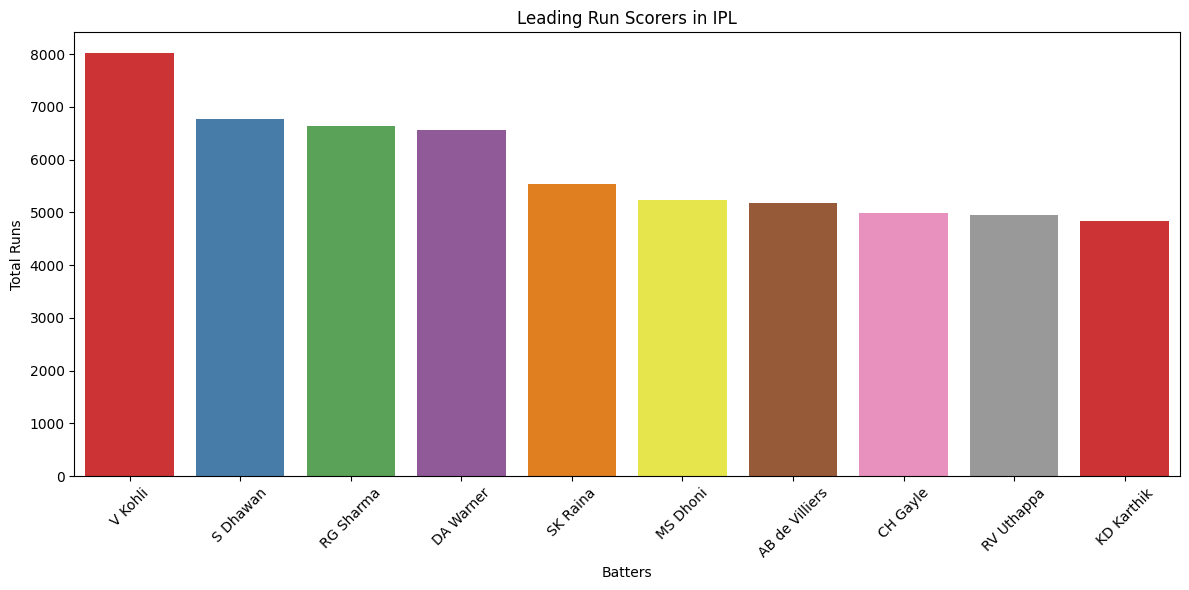

In [12]:
#VISULISING TOP BATTERES
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_batters["batter"],
    y=top_batters["batsman_runs"],
    palette="Set1"
    )
plt.title("Leading Run Scorers in IPL")
plt.xticks(rotation=45)
plt.xlabel("Batters")
plt.ylabel("Total Runs")
plt.tight_layout()
plt.savefig("top_batters.png", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
#Most 50s and 100s
batsman_run_by_match=data.groupby(["batter","match_id"])["batsman_runs"].sum().reset_index()
batsman_run_by_match["100"]=batsman_run_by_match["batsman_runs"].apply(lambda x: 1 if x>=100 else 0)
batsman_run_by_match["50"]=batsman_run_by_match["batsman_runs"].apply(lambda x: 1 if 50<=x<100 else 0)

most_century_AND_halfCentury=batsman_run_by_match.groupby("batter")[["100","50"]].sum().sort_values(by="100",ascending=False).reset_index().head(10)
most_century_AND_halfCentury

,batter,100,50
0,V Kohli,8,56
1,JC Buttler,7,19
2,CH Gayle,6,32
3,DA Warner,4,62
4,KL Rahul,4,37
5,SR Watson,4,21
6,Shubman Gill,4,20
7,AB de Villiers,3,41
8,SV Samson,3,25
9,BB McCullum,2,13


C:\Users\hp\AppData\Local\Temp\ipykernel_13076\2559211183.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_13076\2559211183.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


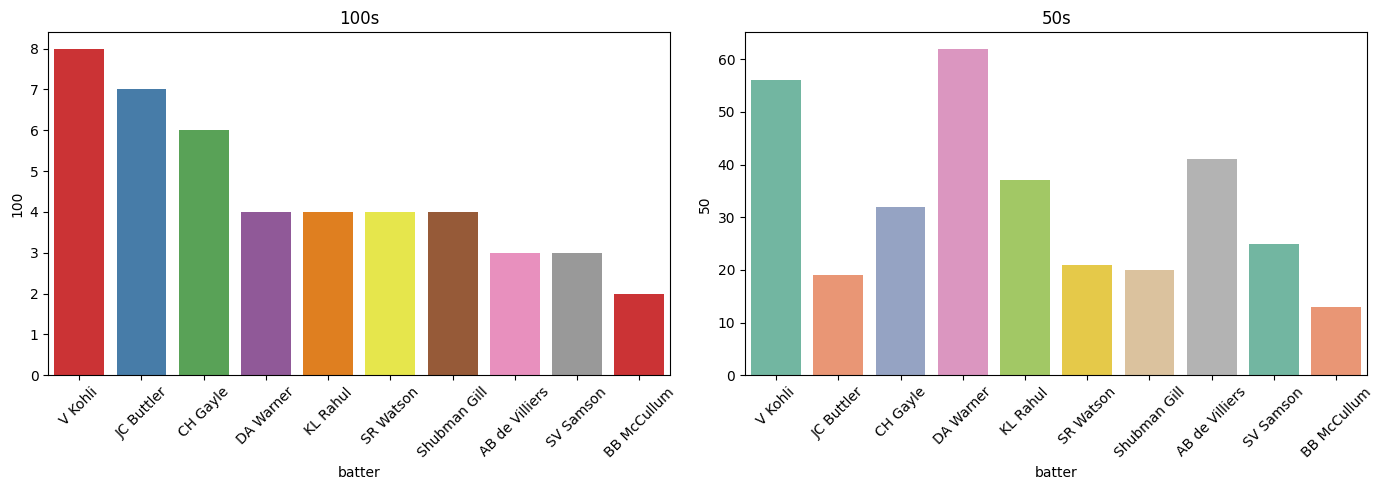

In [13]:
#Visualization Most 50s and 100s
plt.figure(figsize=(14,5))
# first graph
plt.subplot(1,2,1)
sns.barplot(
    data=most_century_AND_halfCentury,
    x="batter",
    y="100",
    palette="Set1"
)
plt.title("100s")
plt.xticks(rotation=45)

# second graph
plt.subplot(1,2,2)
sns.barplot(
    data=most_century_AND_halfCentury,
    x="batter",
    y="50",
    palette="Set2"
)
plt.title("50s")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("most_50_100s.png", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
#Strike Rate
total_ball_faced=data.groupby("batter")["ball"].count().reset_index()
total_ball_faced
total_run=data.groupby("batter")["batsman_runs"].sum().reset_index()
total_run
batsman_stats=total_run.merge(total_ball_faced,on="batter")
batsman_stats["strike_rate"]=(batsman_stats["batsman_runs"]/batsman_stats["ball"])*100
batsman_stats=batsman_stats.sort_values(by="strike_rate",ascending=False).head(10).reset_index(drop=True).sort_values(by="strike_rate",ascending=False)
batsman_stats

,batter,batsman_runs,ball,strike_rate
0,L Wood,9,3,300.000000
1,B Stanlake,5,2,250.000000
2,J Fraser-McGurk,330,150,220.000000
3,R Sai Kishore,13,6,216.666667
4,Umar Gul,39,19,205.263158
5,RS Sodhi,4,2,200.000000
6,Shahid Afridi,81,46,176.086957
7,I Malhotra,7,4,175.000000
8,WG Jacks,230,133,172.932331
9,PD Salt,653,385,169.610390


C:\Users\hp\AppData\Local\Temp\ipykernel_13076\557697519.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


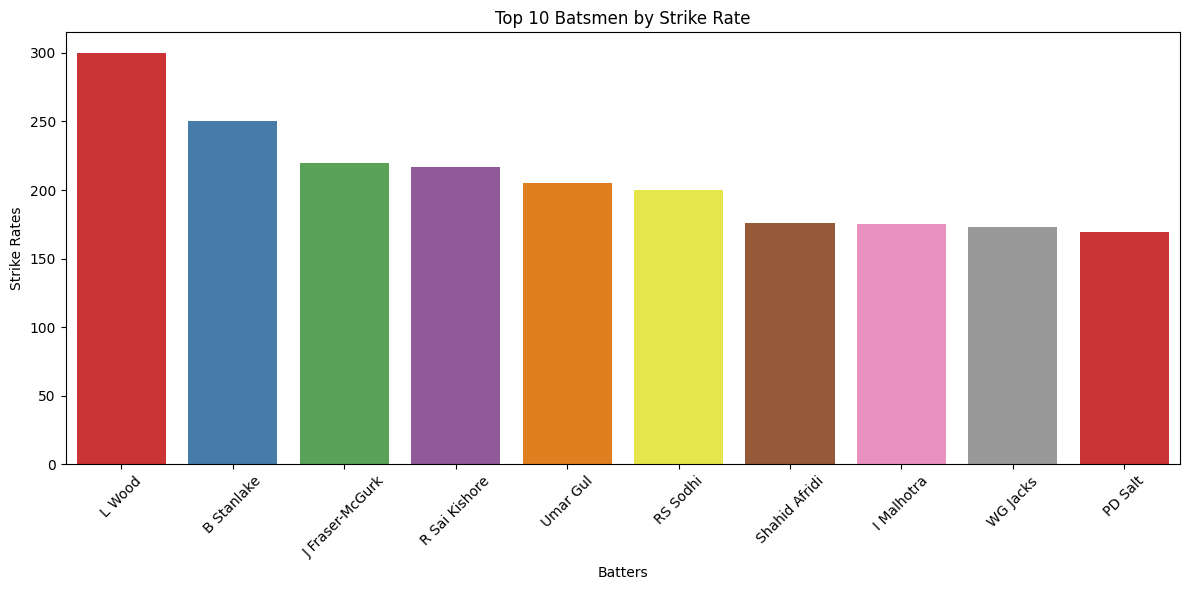

In [15]:
#Visualization strike rate
plt.figure(figsize=(12,6))
sns.barplot(
    data=batsman_stats,
    x="batter",
    y="strike_rate",
    palette="Set1"
)

plt.title("Top 10 Batsmen by Strike Rate")
plt.xticks(rotation=45)
plt.xlabel("Batters")
plt.ylabel("Strike Rates")

plt.tight_layout()
plt.savefig("strike_rate.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
#Bowling Analysis (Top Bowlers by Wickets)
top_bowlers=data[data['is_wicket']==1].groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10)
top_bowlers=top_bowlers.reset_index().sort_values(by="is_wicket",ascending=False)
top_bowlers

,bowler,is_wicket
0,YS Chahal,213
1,DJ Bravo,207
2,PP Chawla,201
3,SP Narine,200
4,R Ashwin,198
5,B Kumar,195
6,SL Malinga,188
7,A Mishra,183
8,JJ Bumrah,182
9,RA Jadeja,169


C:\Users\hp\AppData\Local\Temp\ipykernel_13076\2234265610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


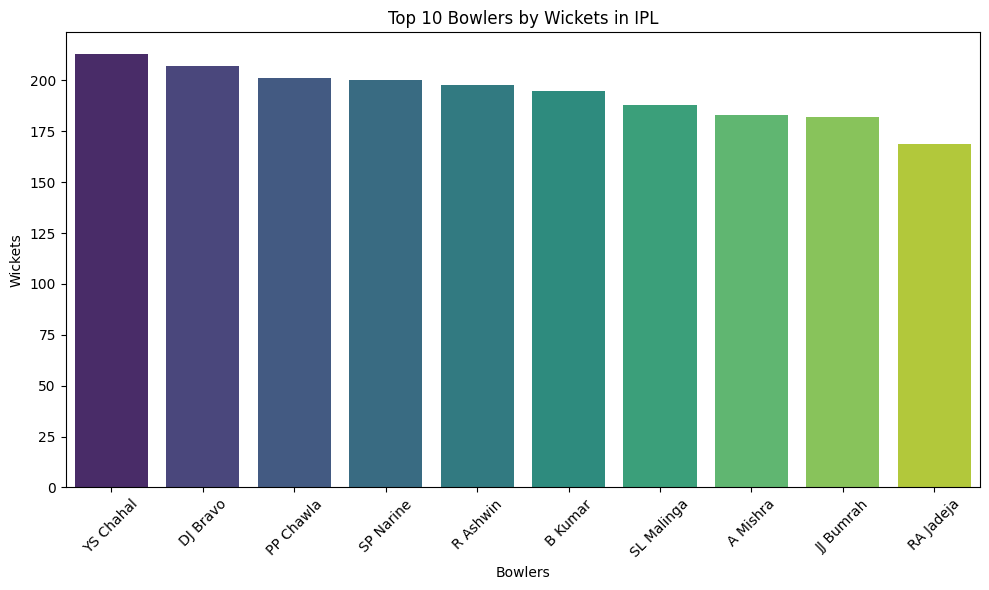

In [17]:
# Visualization(Bowling Analysis (Top Bowlers by Wickets))
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_bowlers,
    x="bowler",
    y="is_wicket",
    palette="viridis"
)
plt.title("Top 10 Bowlers by Wickets in IPL")
plt.xlabel("Bowlers")
plt.ylabel("Wickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top_bowlers.png", dpi=300, bbox_inches='tight')
plt.show()

In [18]:
#best economical bowler
balls_bowled=data.groupby("bowler")["ball"].count().reset_index()
bowler_runs=data.groupby("bowler")["total_runs"].sum().reset_index()

bowler_stats=bowler_runs.merge(balls_bowled,on="bowler")
bowler_stats["overs"]=bowler_stats["ball"]/6
#economy calculate #
bowler_stats["economy"]=bowler_stats["total_runs"]/bowler_stats["overs"]
bowler_stats=bowler_stats.sort_values("economy").head(10).reset_index(drop=True)
bowler_stats

,bowler,total_runs,ball,overs,economy
0,AC Gilchrist,0,1,0.166667,0.000000
1,R Ravindra,7,12,2.000000,3.500000
2,NB Singh,18,25,4.166667,4.320000
3,Sachin Baby,8,10,1.666667,4.800000
4,AM Rahane,5,6,1.000000,5.000000
5,LA Carseldine,6,7,1.166667,5.142857
6,SS Mundhe,6,7,1.166667,5.142857
7,DJ Thornely,40,44,7.333333,5.454545
8,M Manhas,42,42,7.000000,6.000000
9,MW Short,25,25,4.166667,6.000000


C:\Users\hp\AppData\Local\Temp\ipykernel_13076\2582340668.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


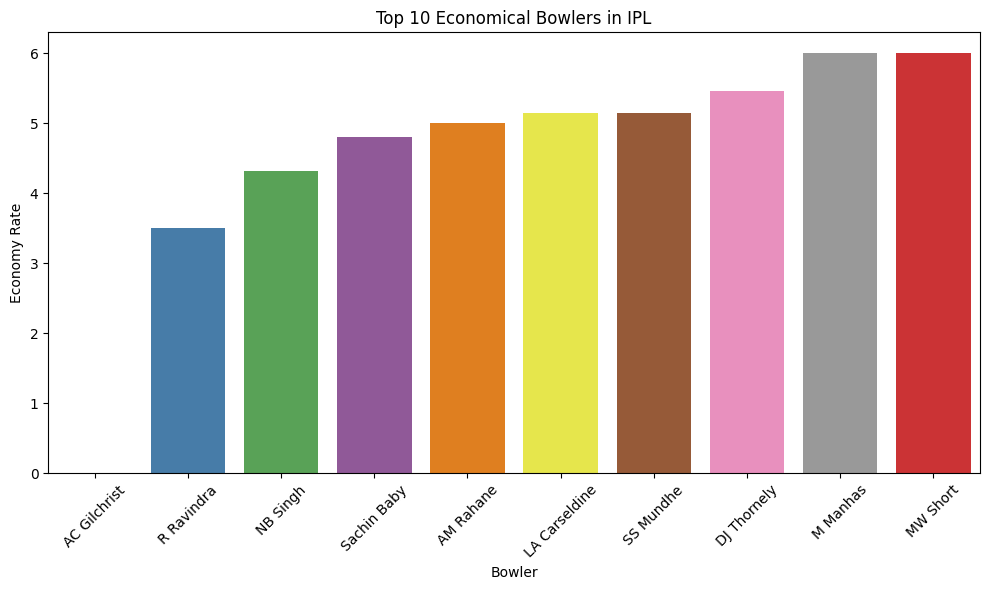

In [19]:
#Visualization(Best Economical Bowlers)
plt.figure(figsize=(10,6))
sns.barplot(
    data=bowler_stats,
    x="bowler",
    y="economy",
    palette="Set1"
)
plt.title("Top 10 Economical Bowlers in IPL")
plt.xlabel("Bowler")
plt.ylabel("Economy Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("economical_bowlers.png", dpi=300, bbox_inches='tight')
plt.show()

In [20]:
#Team Performance
#Standardize Team Names
team_name_map= {
    "Royal Challengers Bangalore":"Royal Challengers Bengaluru",
    "Delhi Daredevils":"Delhi Capitals",
    "Kings XI Punjab":"Punjab Kings",
    "Rising Pune Supergiant":"Pune Supergiant",
    "Rising Pune Supergiants":"Pune Supergiant"
}
#Standardize batting and bowling team names
batting_team=df['batting_team'].replace(team_name_map)
bowling_team=df['bowling_team'].replace(team_name_map)

#match winners finding
match_scores=df.groupby(['match_id','batting_team'])['total_runs'].sum().reset_index()
match_scores['batting_team']=match_scores['batting_team'].replace(team_name_map)
match_winners=match_scores.loc[match_scores.groupby('match_id')['total_runs'].idxmax()]

#Total matches played per team (1 per team per match)
all_teams=pd.concat([
    df[['match_id']].assign(team=batting_team),
    df[['match_id']].assign(team=bowling_team)
]).drop_duplicates()
matches_played=all_teams.groupby('team')['match_id'].count().reset_index(name='matches_played')

#Total wins per team
wins=match_winners['batting_team'].value_counts().reset_index()
wins.columns=['team','wins']

#Merge matches and wins calculate losses
team_stats=matches_played.merge(wins,on='team',how='left').fillna(0)
team_stats['wins']=team_stats['wins'].astype(int)
team_stats['losses']=team_stats['matches_played']-team_stats['wins']

#team stats
team_stats

,team,matches_played,wins,losses
0,Chennai Super Kings,238,137,101
1,Deccan Chargers,75,29,46
2,Delhi Capitals,252,119,133
3,Gujarat Lions,30,13,17
4,Gujarat Titans,45,29,16
5,Kochi Tuskers Kerala,14,6,8
6,Kolkata Knight Riders,251,130,121
7,Lucknow Super Giants,44,25,19
8,Mumbai Indians,261,144,117
9,Pune Supergiant,30,14,16


C:\Users\hp\AppData\Local\Temp\ipykernel_13076\2357808231.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_stats, x='team', y='wins', palette='Set2')


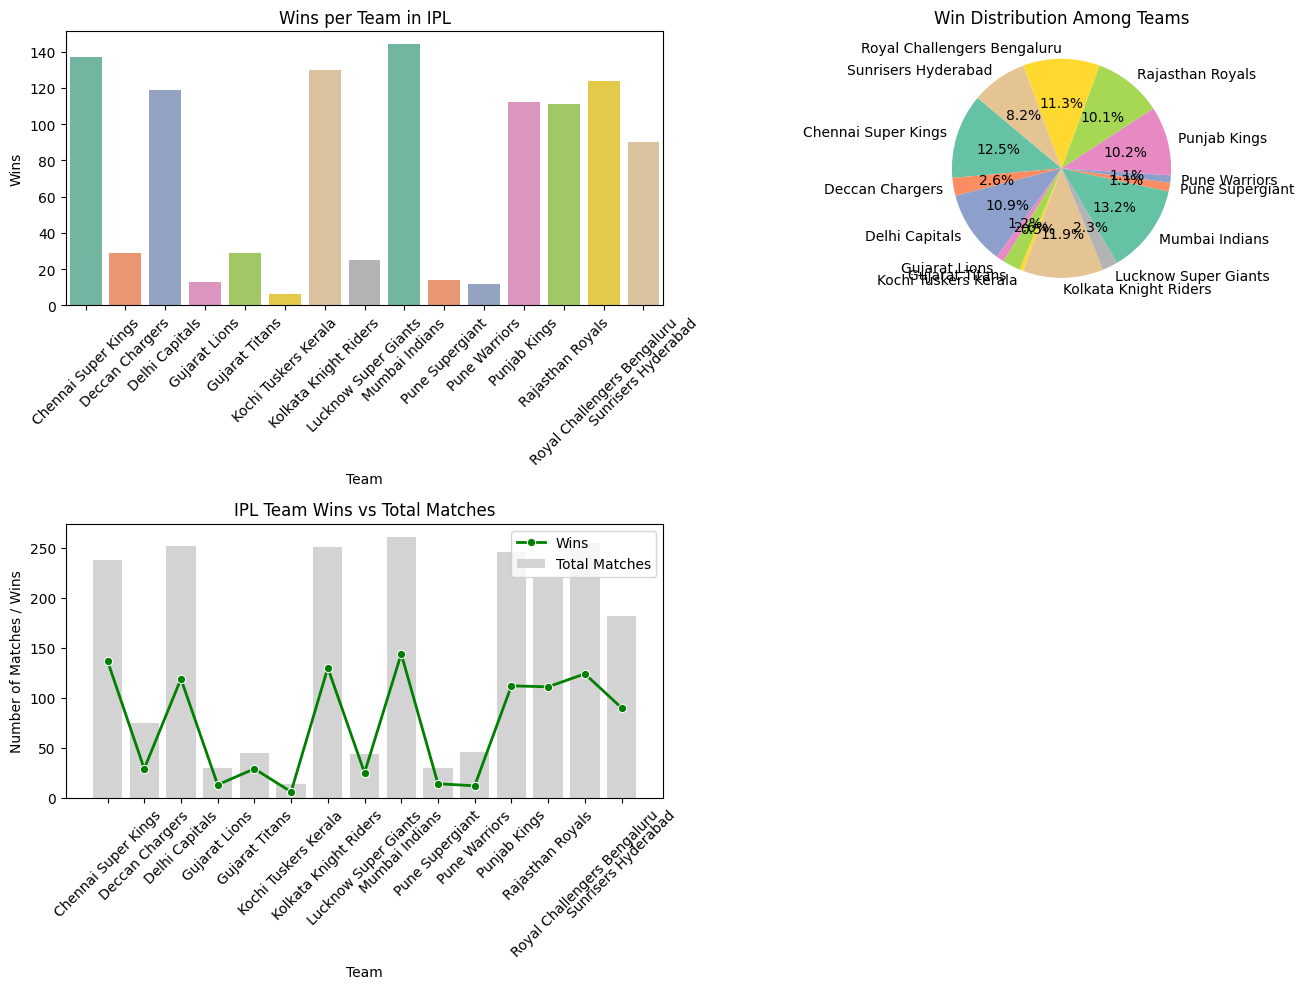

In [22]:
#Team Stats Visualization
plt.figure(figsize=(14,10))
#bar plot
plt.subplot(2, 2, 1)
sns.barplot(data=team_stats, x='team', y='wins', palette='Set2')
plt.title("Wins per Team in IPL")
plt.xticks(rotation=45)
plt.xlabel("Team")
plt.ylabel("Wins")

#pie chart
plt.subplot(2, 2, 2)
plt.pie(team_stats['wins'], labels=team_stats['team'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title("Win Distribution Among Teams")

#line plot
plt.subplot(2, 2, 3)
sns.barplot(data=team_stats, x='team', y='matches_played', color='lightgray', label='Total Matches')
sns.lineplot(data=team_stats, x='team', y='wins', marker='o', color='green', linewidth=2, label='Wins')
plt.title("IPL Team Wins vs Total Matches")
plt.xlabel("Team")
plt.ylabel("Number of Matches / Wins")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.savefig("team_stats_composite.png", dpi=300, bbox_inches='tight')
plt.show()

In [23]:
import os
os.getcwd()

'E:\\AIML\\jupyterlab\\ALLinONE\\DataAnalytics'